In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Input

# Process images and labels
def process_image(image_path):
    image = load_img(image_path, target_size=(224, 224))  # Resize image to 224x224
    image = img_to_array(image) / 255.0  # Convert image to array and normalize
    return image

images_loc = []
labels = []

# Define the directories
forest_fire_dataset_path = '/kaggle/input/forest-fire-image-dataset/FOREST_FIRE_DATASET'
fire_dir = os.path.join(forest_fire_dataset_path, 'FIRE')
non_fire_dir = os.path.join(forest_fire_dataset_path, 'NON_FIRE')

# Check and process images in FIRE directory
if os.path.exists(fire_dir):
    for i in os.listdir(fire_dir):
        images_loc.append(process_image(os.path.join(fire_dir, i)))
        labels.append(0)
else:
    print(f"Directory {fire_dir} does not exist.")

# Check and process images in NON_FIRE directory
if os.path.exists(non_fire_dir):
    for i in os.listdir(non_fire_dir):
        images_loc.append(process_image(os.path.join(non_fire_dir, i)))
        labels.append(1)
else:
    print(f"Directory {non_fire_dir} does not exist.")

print(f"Processed {len(images_loc)} images.")


In [ ]:
from sklearn.model_selection import train_test_split
import shutil
import os

# Paths to FIRE and NON_FIRE directories
fire_dir = '/kaggle/input/forest-fire-image-dataset/FOREST_FIRE_DATASET/FIRE'
non_fire_dir = '/kaggle/input/forest-fire-image-dataset/FOREST_FIRE_DATASET/NON_FIRE'

# Temporary directories for train and test splits
train_dir = '/kaggle/working/Train_Data'
test_dir = '/kaggle/working/Test_Data'

# Create necessary directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(os.path.join(train_dir, 'FIRE'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'NON_FIRE'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'FIRE'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'NON_FIRE'), exist_ok=True)

# Function to split and copy files
def split_dataset(source_dir, train_dest, test_dest, split_ratio=0.6):
    files = os.listdir(source_dir)
    train_files, test_files = train_test_split(files, test_size=1-split_ratio, random_state=42)
    for file in train_files:
        shutil.copy(os.path.join(source_dir, file), os.path.join(train_dest, file))
    for file in test_files:
        shutil.copy(os.path.join(source_dir, file), os.path.join(test_dest, file))

# Split the datasets for FIRE and NON_FIRE
split_dataset(fire_dir, os.path.join(train_dir, 'FIRE'), os.path.join(test_dir, 'FIRE'))
split_dataset(non_fire_dir, os.path.join(train_dir, 'NON_FIRE'), os.path.join(test_dir, 'NON_FIRE'))


# Resnet50

In [4]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Input

# Paths for train and test data
train_dir = '/kaggle/working/Train_Data'
test_dir = '/kaggle/working/Test_Data'

# Define ImageDataGenerators for train and test
datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load ResNet50 model without the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add a custom head for feature extraction
input_layer = Input(shape=(224, 224, 3))
x = base_model(input_layer, training=False)
x = Flatten()(x)
feature_extractor = Model(inputs=input_layer, outputs=x)

# Extract features for training data
train_features = feature_extractor.predict(train_generator)
train_labels = train_generator.classes

# Extract features for test data
test_features = feature_extractor.predict(test_generator)
test_labels = test_generator.classes

# Save the extracted features
np.save('/kaggle/working/train_features_resnet50.npy', train_features)
np.save('/kaggle/working/train_labels_resnet50.npy', train_labels)
np.save('/kaggle/working/test_features_resnet50.npy', test_features)
np.save('/kaggle/working/test_labels_resnet50.npy', test_labels)


Found 6619 images belonging to 2 classes.
Found 4413 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


207/207 ━━━━━━━━━━━━━━━━━━━━ 44s 187ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 188ms/step


Resnet50+Decistion tree

Decision Tree Test Accuracy: 79.11%


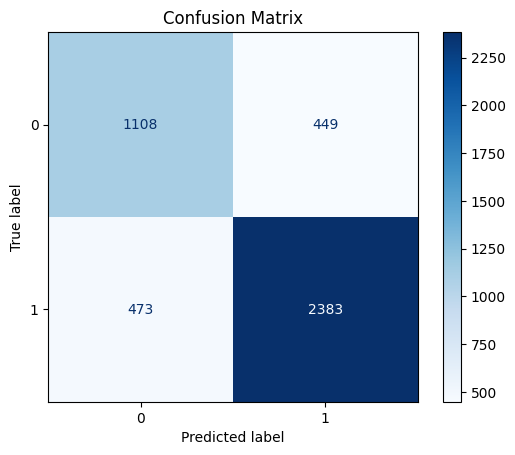

Accuracy: 79.11%
Precision: 84.15%
Recall: 83.44%
F1 Score: 83.79%


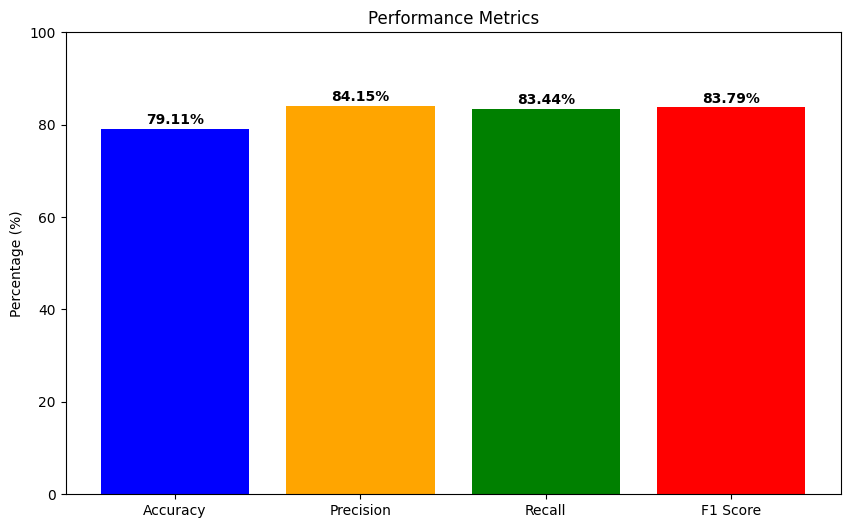

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_resnet50.npy')
train_labels = np.load('/kaggle/working/train_labels_resnet50.npy')
test_features = np.load('/kaggle/working/test_features_resnet50.npy')
test_labels = np.load('/kaggle/working/test_labels_resnet50.npy')

# Initialize and train the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_dt = dt_classifier.predict(test_features)

# Calculate accuracy
accuracy_dt = accuracy_score(test_labels, test_predictions_dt)
print(f"Decision Tree Test Accuracy: {accuracy_dt * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Resnet50+naiv boyes

Naive Bayes Test Accuracy: 50.33%


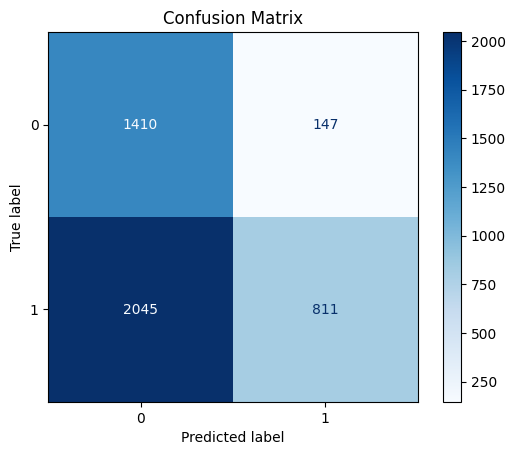

Accuracy: 50.33%
Precision: 84.66%
Recall: 28.40%
F1 Score: 42.53%


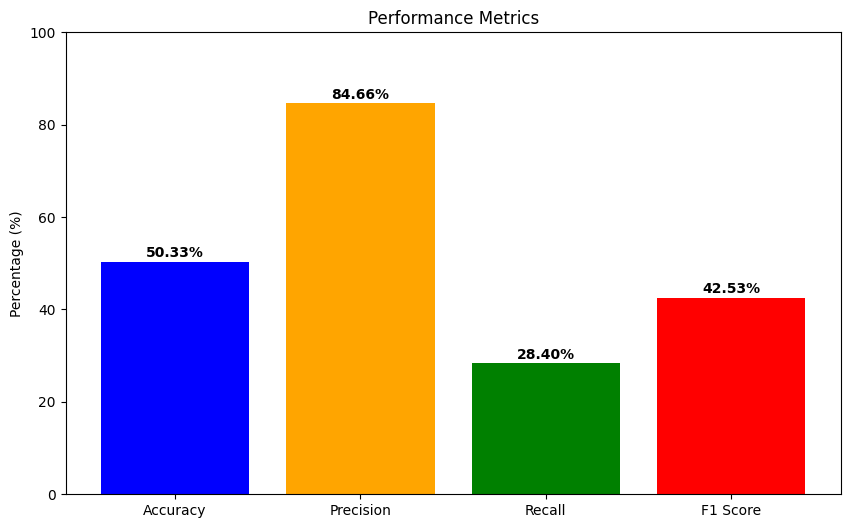

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_resnet50.npy')
train_labels = np.load('/kaggle/working/train_labels_resnet50.npy')
test_features = np.load('/kaggle/working/test_features_resnet50.npy')
test_labels = np.load('/kaggle/working/test_labels_resnet50.npy')

# Initialize and train the Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_nb = nb_classifier.predict(test_features)

# Calculate accuracy
accuracy_nb = accuracy_score(test_labels, test_predictions_nb)
print(f"Naive Bayes Test Accuracy: {accuracy_nb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Resnet50+Xgboost

XGBoost Test Accuracy: 91.00%


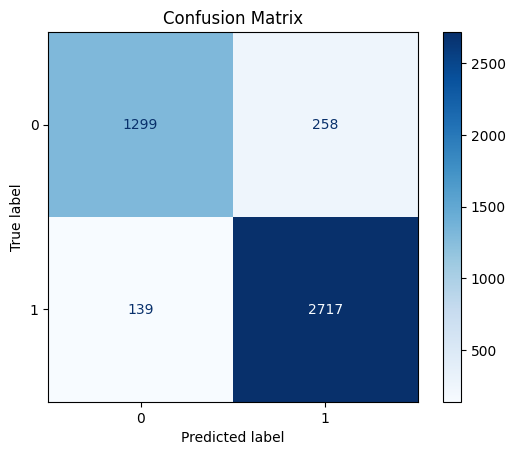

Accuracy: 91.00%
Precision: 91.33%
Recall: 95.13%
F1 Score: 93.19%


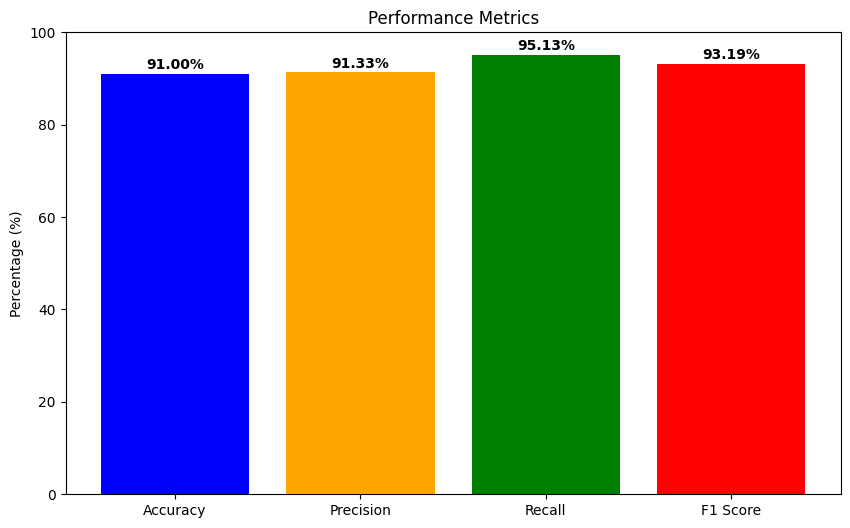

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_resnet50.npy')
train_labels = np.load('/kaggle/working/train_labels_resnet50.npy')
test_features = np.load('/kaggle/working/test_features_resnet50.npy')
test_labels = np.load('/kaggle/working/test_labels_resnet50.npy')

# Initialize and train the XGBoost classifier
xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_xgb = xgb_classifier.predict(test_features)

# Calculate accuracy
accuracy_xgb = accuracy_score(test_labels, test_predictions_xgb)
print(f"XGBoost Test Accuracy: {accuracy_xgb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Resnet50+Svm

SVM Test Accuracy: 89.44%


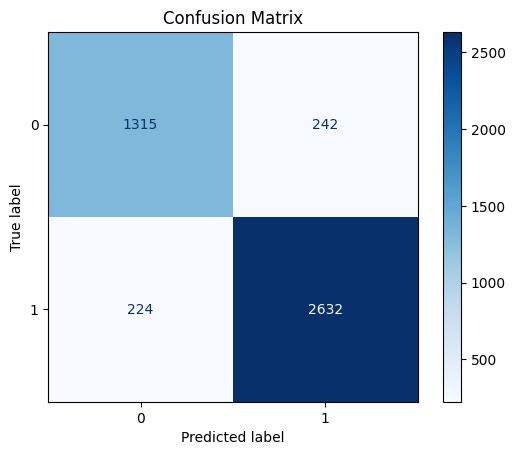

Accuracy: 89.44%
Precision: 91.58%
Recall: 92.16%
F1 Score: 91.87%


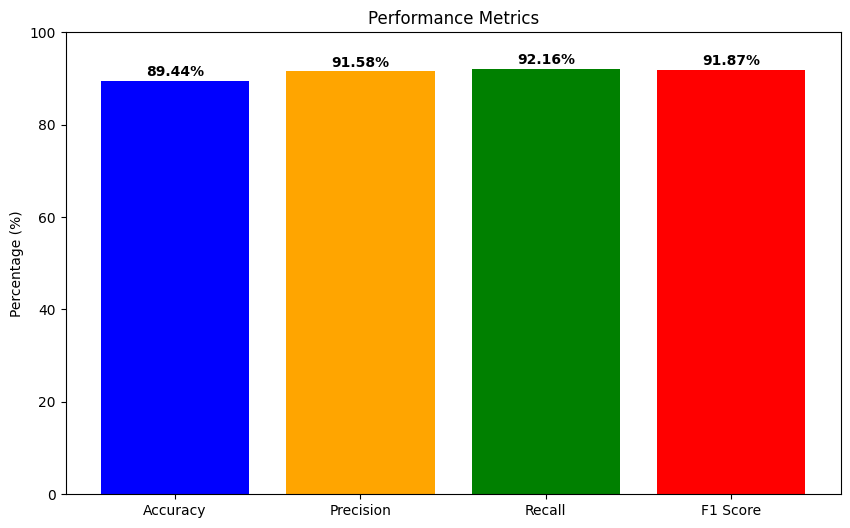

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_resnet50.npy')
train_labels = np.load('/kaggle/working/train_labels_resnet50.npy')
test_features = np.load('/kaggle/working/test_features_resnet50.npy')
test_labels = np.load('/kaggle/working/test_labels_resnet50.npy')

# Initialize and train the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_svm = svm_classifier.predict(test_features)

# Calculate accuracy
accuracy_svm = accuracy_score(test_labels, test_predictions_svm)
print(f"SVM Test Accuracy: {accuracy_svm * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


ResNet50+RandomForest

Random Forest Test Accuracy: 88.01%


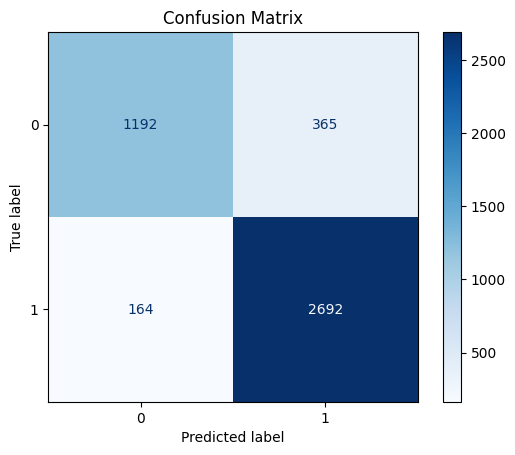

Accuracy: 88.01%
Precision: 88.06%
Recall: 94.26%
F1 Score: 91.05%


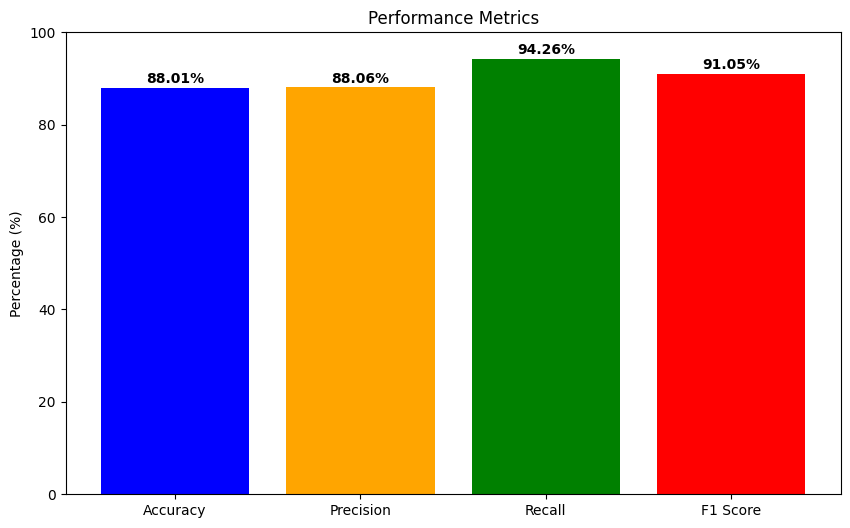

In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_resnet50.npy')
train_labels = np.load('/kaggle/working/train_labels_resnet50.npy')
test_features = np.load('/kaggle/working/test_features_resnet50.npy')
test_labels = np.load('/kaggle/working/test_labels_resnet50.npy')

# Initialize and train the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_rf = rf_classifier.predict(test_features)

# Calculate accuracy
accuracy_rf = accuracy_score(test_labels, test_predictions_rf)
print(f"Random Forest Test Accuracy: {accuracy_rf * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


**MobileNetV3**

In [4]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Input

# Paths for train and test data
train_dir = '/kaggle/working/Train_Data'
test_dir = '/kaggle/working/Test_Data'

# Define ImageDataGenerators for train and test
datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load MobileNetV3 model without the top layer
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add a custom head for feature extraction
input_layer = Input(shape=(224, 224, 3))
x = base_model(input_layer, training=False)
x = Flatten()(x)
feature_extractor = Model(inputs=input_layer, outputs=x)

# Extract features for training data
train_features = feature_extractor.predict(train_generator)
train_labels = train_generator.classes

# Extract features for test data
test_features = feature_extractor.predict(test_generator)
test_labels = test_generator.classes

# Save the extracted features
np.save('/kaggle/working/train_features_mobilenetv3.npy', train_features)
np.save('/kaggle/working/train_labels_mobilenetv3.npy', train_labels)
np.save('/kaggle/working/test_features_mobilenetv3.npy', test_features)
np.save('/kaggle/working/test_labels_mobilenetv3.npy', test_labels)


Found 6619 images belonging to 2 classes.
Found 4413 images belonging to 2 classes.
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


207/207 ━━━━━━━━━━━━━━━━━━━━ 45s 189ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 197ms/step


MobileNetV3+naiv voyes

Naive Bayes Test Accuracy: 44.57%


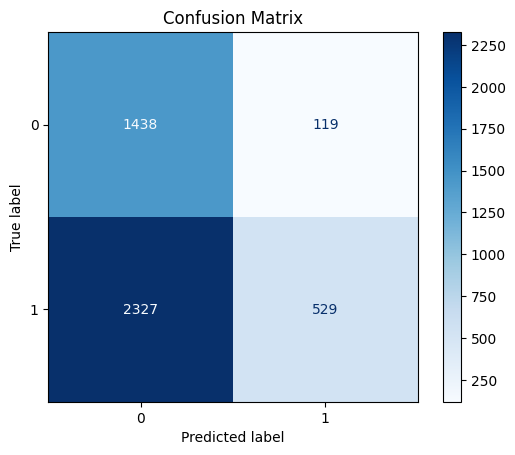

Accuracy: 44.57%
Precision: 81.64%
Recall: 18.52%
F1 Score: 30.19%


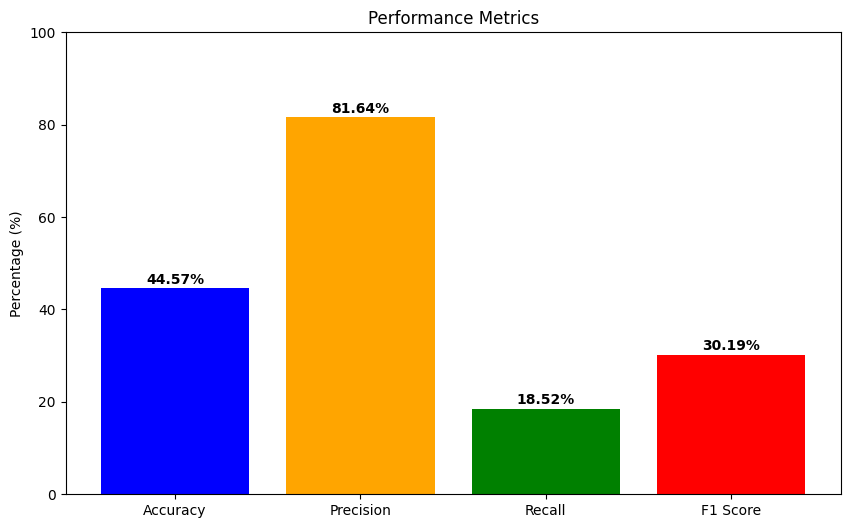

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_mobilenetv3.npy')
train_labels = np.load('/kaggle/working/train_labels_mobilenetv3.npy')
test_features = np.load('/kaggle/working/test_features_mobilenetv3.npy')
test_labels = np.load('/kaggle/working/test_labels_mobilenetv3.npy')

# Initialize and train the Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_nb = nb_classifier.predict(test_features)

# Calculate accuracy
accuracy_nb = accuracy_score(test_labels, test_predictions_nb)
print(f"Naive Bayes Test Accuracy: {accuracy_nb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


MobilnetV3+Decistiontree

Decision Tree Test Accuracy: 74.69%


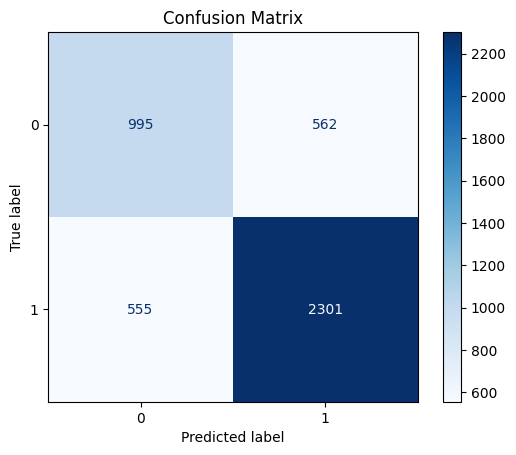

Accuracy: 74.69%
Precision: 80.37%
Recall: 80.57%
F1 Score: 80.47%


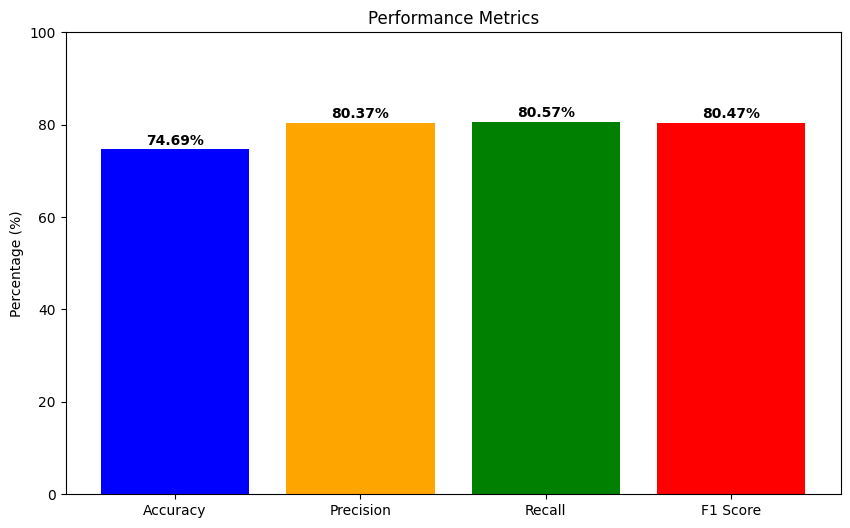

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_mobilenetv3.npy')
train_labels = np.load('/kaggle/working/train_labels_mobilenetv3.npy')
test_features = np.load('/kaggle/working/test_features_mobilenetv3.npy')
test_labels = np.load('/kaggle/working/test_labels_mobilenetv3.npy')

# Initialize and train the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_dt = dt_classifier.predict(test_features)

# Calculate accuracy
accuracy_dt = accuracy_score(test_labels, test_predictions_dt)
print(f"Decision Tree Test Accuracy: {accuracy_dt * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


MobilnetV3+Xgboost

XGBoost Test Accuracy: 88.15%


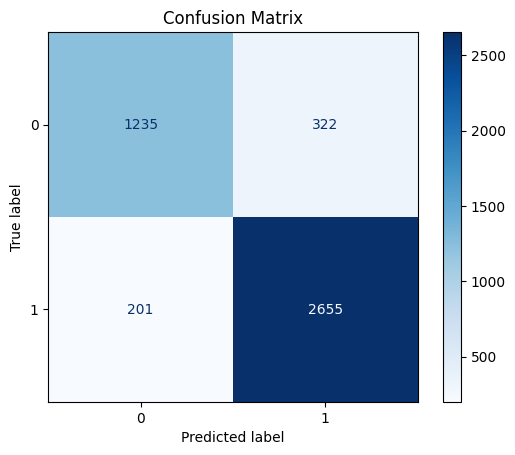

Accuracy: 88.15%
Precision: 89.18%
Recall: 92.96%
F1 Score: 91.03%


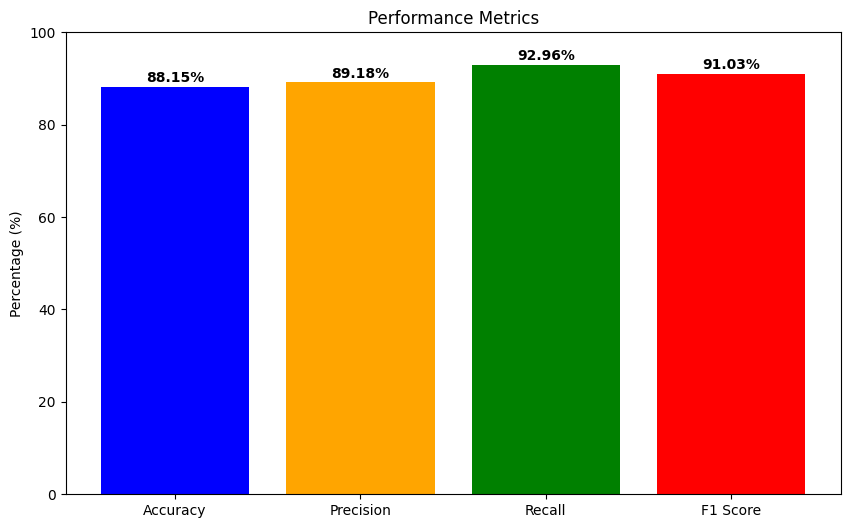

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_mobilenetv3.npy')
train_labels = np.load('/kaggle/working/train_labels_mobilenetv3.npy')
test_features = np.load('/kaggle/working/test_features_mobilenetv3.npy')
test_labels = np.load('/kaggle/working/test_labels_mobilenetv3.npy')

# Initialize and train the XGBoost classifier
xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_xgb = xgb_classifier.predict(test_features)

# Calculate accuracy
accuracy_xgb = accuracy_score(test_labels, test_predictions_xgb)
print(f"XGBoost Test Accuracy: {accuracy_xgb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


MobileNetV3+SVM

SVM Test Accuracy: 86.90%


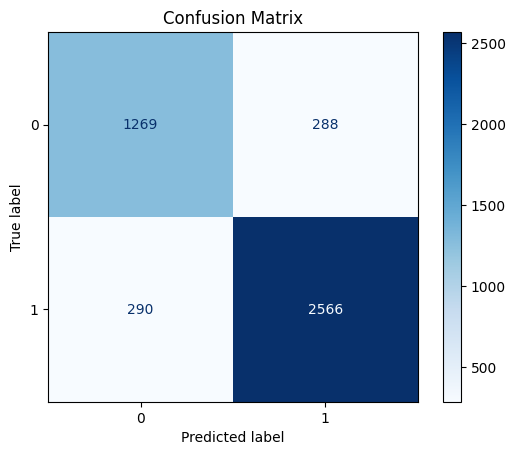

Accuracy: 86.90%
Precision: 89.91%
Recall: 89.85%
F1 Score: 89.88%


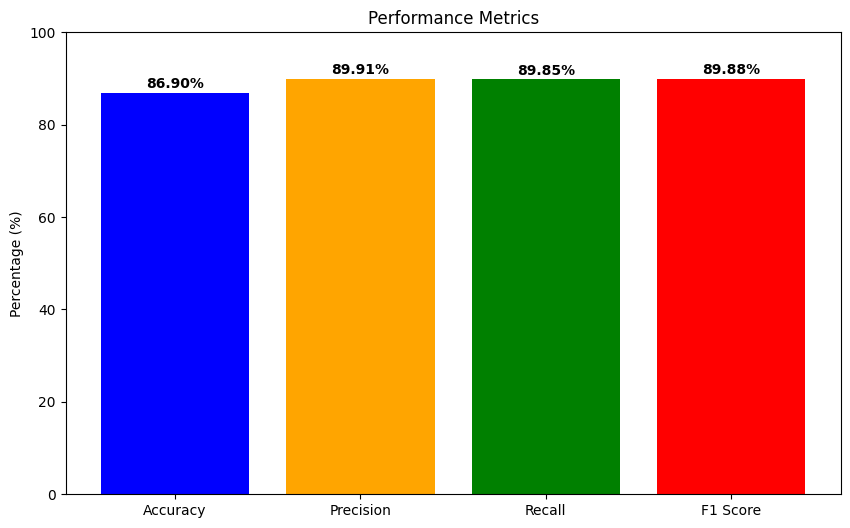

In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_mobilenetv3.npy')
train_labels = np.load('/kaggle/working/train_labels_mobilenetv3.npy')
test_features = np.load('/kaggle/working/test_features_mobilenetv3.npy')
test_labels = np.load('/kaggle/working/test_labels_mobilenetv3.npy')

# Initialize and train the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_svm = svm_classifier.predict(test_features)

# Calculate accuracy
accuracy_svm = accuracy_score(test_labels, test_predictions_svm)
print(f"SVM Test Accuracy: {accuracy_svm * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


MobileNetV3+RandomForest

Random Forest Test Accuracy: 84.02%


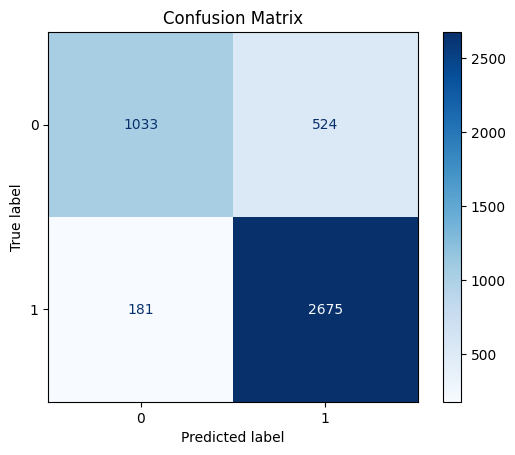

Accuracy: 84.02%
Precision: 83.62%
Recall: 93.66%
F1 Score: 88.36%


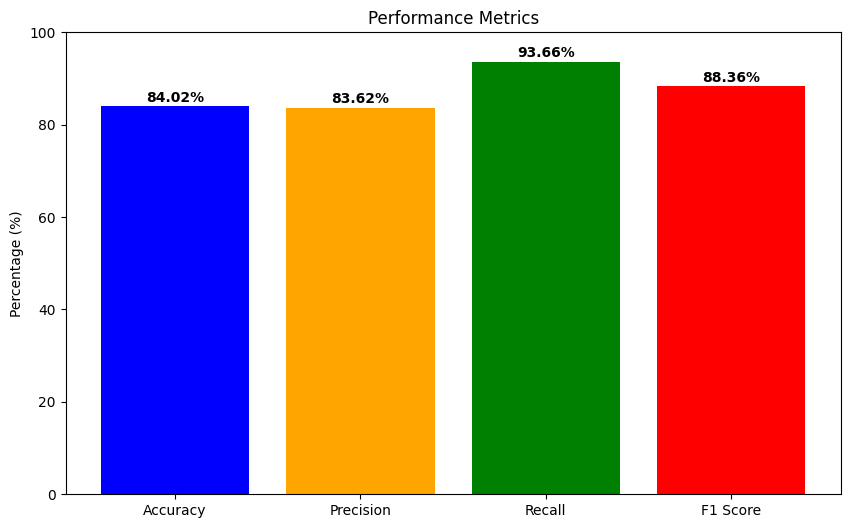

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_mobilenetv3.npy')
train_labels = np.load('/kaggle/working/train_labels_mobilenetv3.npy')
test_features = np.load('/kaggle/working/test_features_mobilenetv3.npy')
test_labels = np.load('/kaggle/working/test_labels_mobilenetv3.npy')

# Initialize and train the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_rf = rf_classifier.predict(test_features)

# Calculate accuracy
accuracy_rf = accuracy_score(test_labels, test_predictions_rf)
print(f"Random Forest Test Accuracy: {accuracy_rf * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


**DenseNet121**

In [11]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Input

# Paths for train and test data
train_dir = '/kaggle/working/Train_Data'
test_dir = '/kaggle/working/Test_Data'

# Define ImageDataGenerators for train and test
datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load DenseNet121 model without the top layer
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add a custom head for feature extraction
input_layer = Input(shape=(224, 224, 3))
x = base_model(input_layer, training=False)
x = Flatten()(x)
feature_extractor = Model(inputs=input_layer, outputs=x)

# Extract features for training data
train_features = feature_extractor.predict(train_generator)
train_labels = train_generator.classes

# Extract features for test data
test_features = feature_extractor.predict(test_generator)
test_labels = test_generator.classes

# Save the extracted features
np.save('/kaggle/working/train_features_densenet121.npy', train_features)
np.save('/kaggle/working/train_labels_densenet121.npy', train_labels)
np.save('/kaggle/working/test_features_densenet121.npy', test_features)
np.save('/kaggle/working/test_labels_densenet121.npy', test_labels)


Found 6619 images belonging to 2 classes.
Found 4413 images belonging to 2 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


207/207 ━━━━━━━━━━━━━━━━━━━━ 58s 223ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 31s 225ms/step


Densenet121+Naivboyes

Naive Bayes Test Accuracy: 85.59%


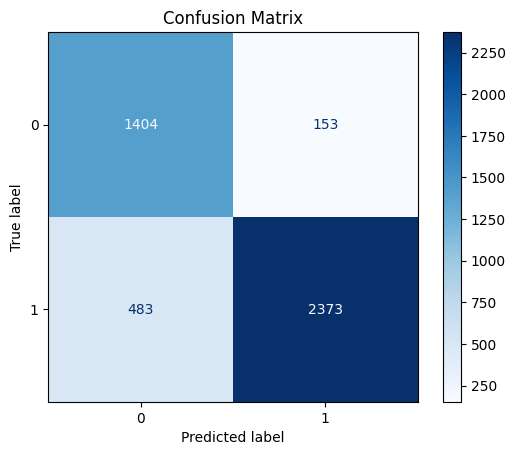

Accuracy: 85.59%
Precision: 93.94%
Recall: 83.09%
F1 Score: 88.18%


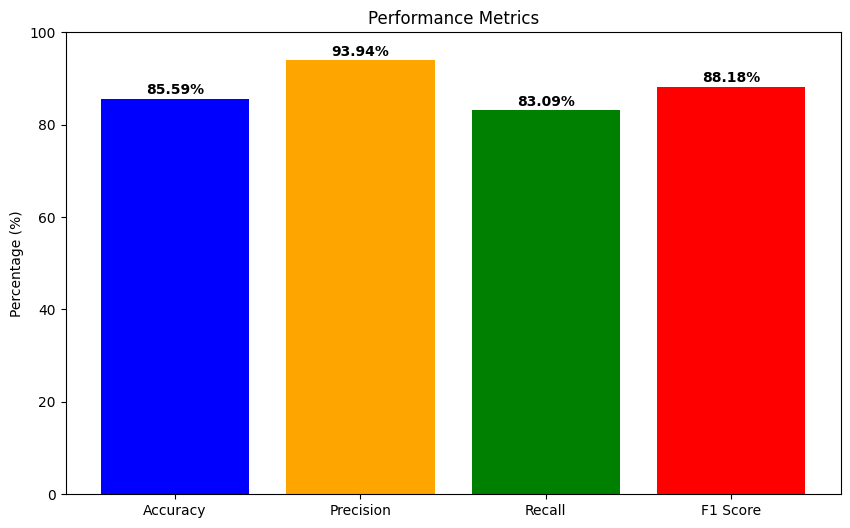

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_densenet121.npy')
train_labels = np.load('/kaggle/working/train_labels_densenet121.npy')
test_features = np.load('/kaggle/working/test_features_densenet121.npy')
test_labels = np.load('/kaggle/working/test_labels_densenet121.npy')

# Initialize and train the Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_nb = nb_classifier.predict(test_features)

# Calculate accuracy
accuracy_nb = accuracy_score(test_labels, test_predictions_nb)
print(f"Naive Bayes Test Accuracy: {accuracy_nb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Denesenet121+Decistiontree

Decision Tree Test Accuracy: 89.01%


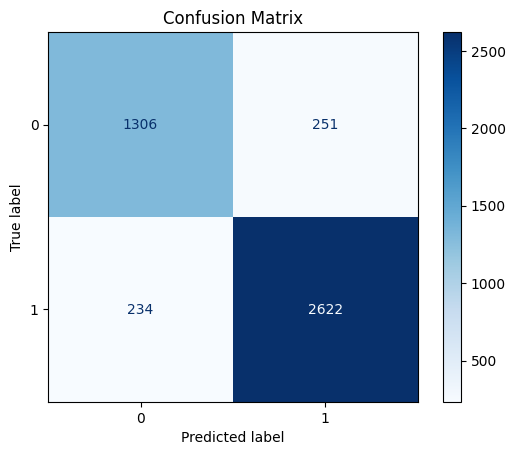

Accuracy: 89.01%
Precision: 91.26%
Recall: 91.81%
F1 Score: 91.53%


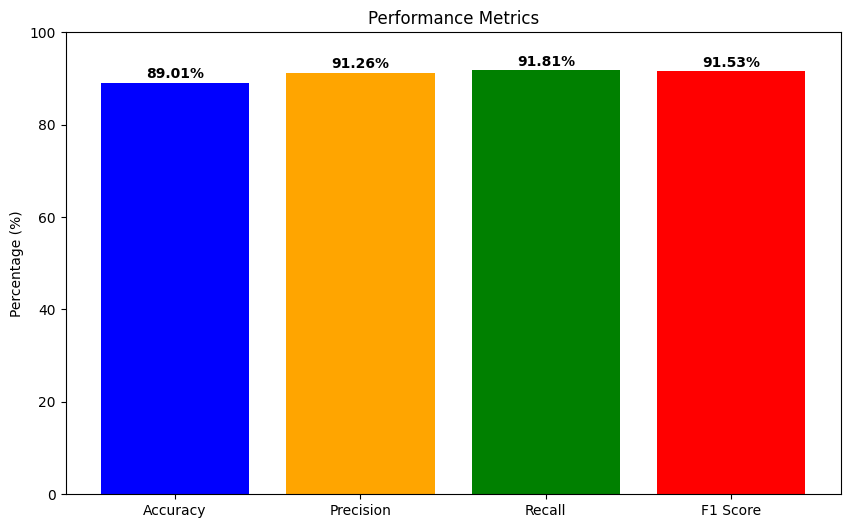

In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_densenet121.npy')
train_labels = np.load('/kaggle/working/train_labels_densenet121.npy')
test_features = np.load('/kaggle/working/test_features_densenet121.npy')
test_labels = np.load('/kaggle/working/test_labels_densenet121.npy')

# Initialize and train the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_dt = dt_classifier.predict(test_features)

# Calculate accuracy
accuracy_dt = accuracy_score(test_labels, test_predictions_dt)
print(f"Decision Tree Test Accuracy: {accuracy_dt * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Densenet121+Xgboost

XGBoost Test Accuracy: 97.35%


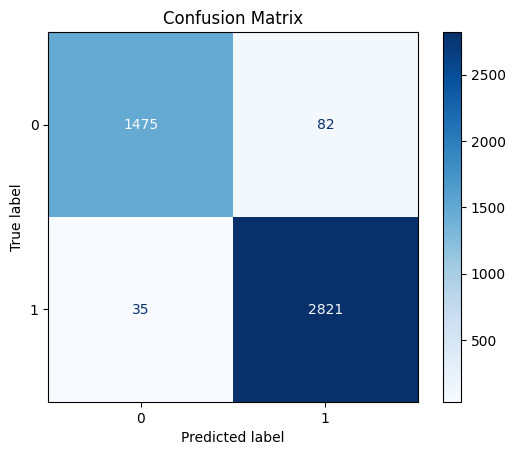

Accuracy: 97.35%
Precision: 97.18%
Recall: 98.77%
F1 Score: 97.97%


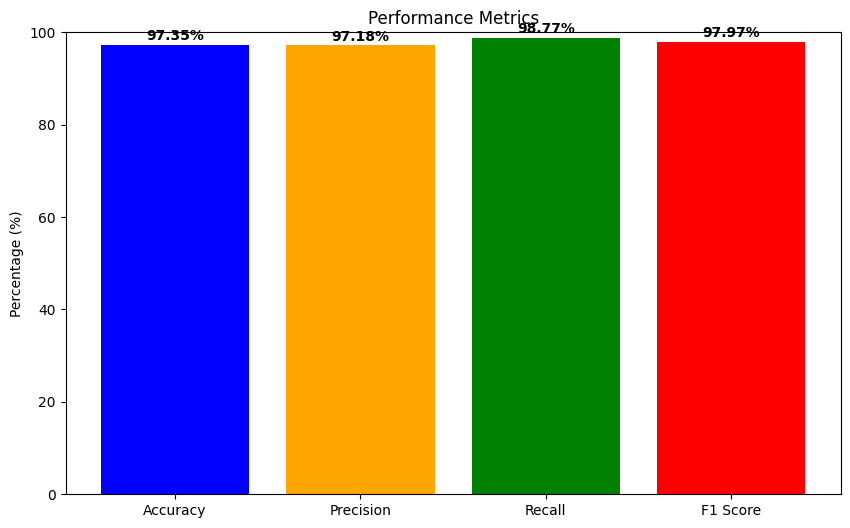

In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_densenet121.npy')
train_labels = np.load('/kaggle/working/train_labels_densenet121.npy')
test_features = np.load('/kaggle/working/test_features_densenet121.npy')
test_labels = np.load('/kaggle/working/test_labels_densenet121.npy')

# Initialize and train the XGBoost classifier
xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_xgb = xgb_classifier.predict(test_features)

# Calculate accuracy
accuracy_xgb = accuracy_score(test_labels, test_predictions_xgb)
print(f"XGBoost Test Accuracy: {accuracy_xgb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


DenseNet121+SVM

SVM Test Accuracy: 97.98%


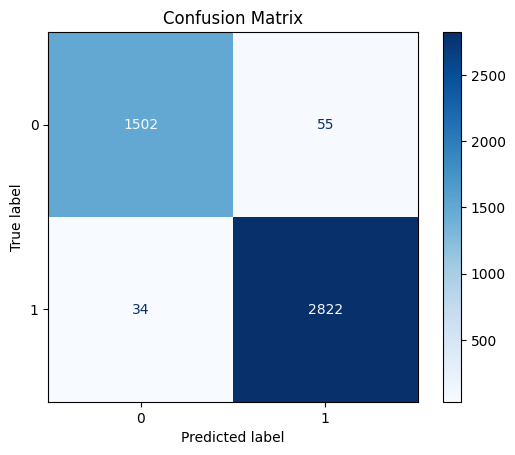

Accuracy: 97.98%
Precision: 98.09%
Recall: 98.81%
F1 Score: 98.45%


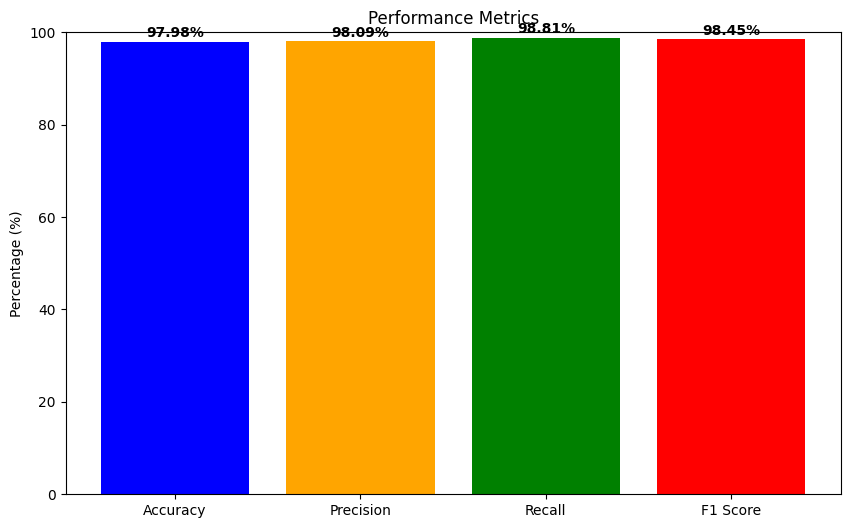

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_densenet121.npy')
train_labels = np.load('/kaggle/working/train_labels_densenet121.npy')
test_features = np.load('/kaggle/working/test_features_densenet121.npy')
test_labels = np.load('/kaggle/working/test_labels_densenet121.npy')

# Initialize and train the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_svm = svm_classifier.predict(test_features)

# Calculate accuracy
accuracy_svm = accuracy_score(test_labels, test_predictions_svm)
print(f"SVM Test Accuracy: {accuracy_svm * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


DenseNet121+randomforest

Random Forest Test Accuracy: 96.37%


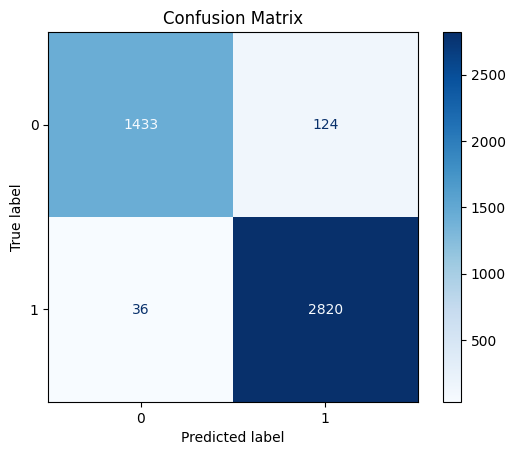

Accuracy: 96.37%
Precision: 95.79%
Recall: 98.74%
F1 Score: 97.24%


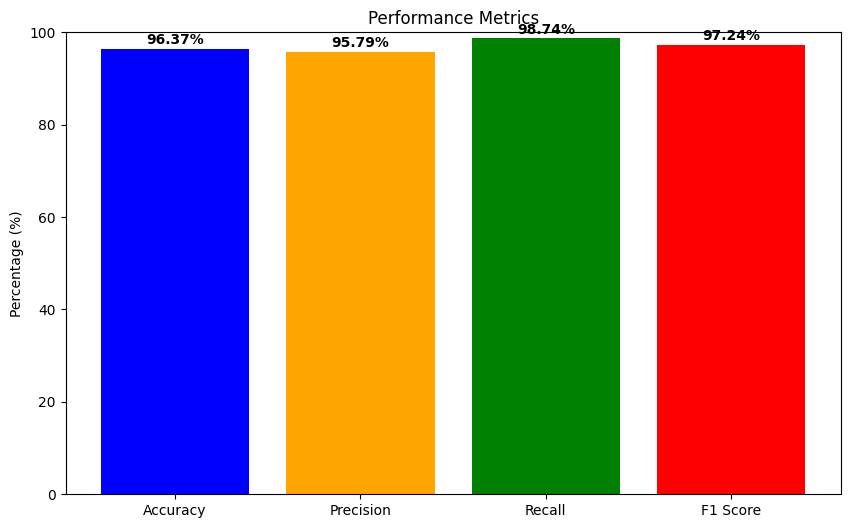

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_densenet121.npy')
train_labels = np.load('/kaggle/working/train_labels_densenet121.npy')
test_features = np.load('/kaggle/working/test_features_densenet121.npy')
test_labels = np.load('/kaggle/working/test_labels_densenet121.npy')

# Initialize and train the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_rf = rf_classifier.predict(test_features)

# Calculate accuracy
accuracy_rf = accuracy_score(test_labels, test_predictions_rf)
print(f"Random Forest Test Accuracy: {accuracy_rf * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()
